# Demo 2 — Error-Gated Hebbian Rule: blind source separation

**Tutorial:** *Synaptic Plasticity and Learning* (CCNSS2026) · Lecture 2

**Idea (Isomura & Toyoizumi 2018, _Sci. Rep._).** A *local* synaptic rule can perform ICA.
Outputs $\mathbf u = W\mathbf x$; the **EGHR-$\beta$** update (ICA case $\beta=0$) is

$$\dot W \;\propto\; -\big\langle\,\underbrace{(E(\mathbf u)-E_0)}_{\text{global error gate}}\;\underbrace{g(\mathbf u)\,\mathbf x^\top}_{\text{Hebbian}}\,\big\rangle,
\qquad E(\mathbf u)=-\log p_0(\mathbf u),\quad g=E'.$$

The bracket factorizes into a **scalar** $(E(\mathbf u)-E_0)$ — a *global* error signal broadcast
to every synapse (a **third factor**, like a neuromodulator) — times a **Hebbian** outer product
$g(u_i)\,x_j$ (post-nonlinearity × presynaptic input). No weight transport, no $W^\top$: every
quantity is locally available. With a **sub-Gaussian (uniform) prior**, $p_0\propto e^{-u^4/4}$,
so $g(u)=u^3$ and $E(\mathbf u)=\tfrac14\sum_i u_i^4$.


In [1]:
import numpy as np
import matplotlib.pyplot as plt

rng = np.random.default_rng(1)
plt.rcParams["figure.dpi"] = 110


## Sources, mixing, and whitening\nThree independent **sub-Gaussian** sources (sine, sawtooth, uniform noise), linearly mixed, then **whitened** (a decorrelation step the retina/LGN performs).

In [2]:
T = 20000
t = np.linspace(0, 1, T)
S = np.vstack([
    np.sin(2*np.pi*7*t),            # sine     (kurtosis ~ -1.5)
    2*((t*11) % 1) - 1,             # sawtooth (sub-Gaussian)
    rng.uniform(-1, 1, T),          # uniform  (sub-Gaussian)
])
S = (S - S.mean(1, keepdims=True)) / S.std(1, keepdims=True)
print("source kurtoses:", np.round((S**4).mean(1) - 3, 2))

A = rng.standard_normal((3, 3))     # random mixing
X = A @ S

Xc = X - X.mean(1, keepdims=True)   # center + ZCA-whiten
d, U = np.linalg.eigh(np.cov(Xc))
Z = (U @ np.diag(1/np.sqrt(d)) @ U.T) @ Xc


source kurtoses: [-1.5  -1.2  -1.21]


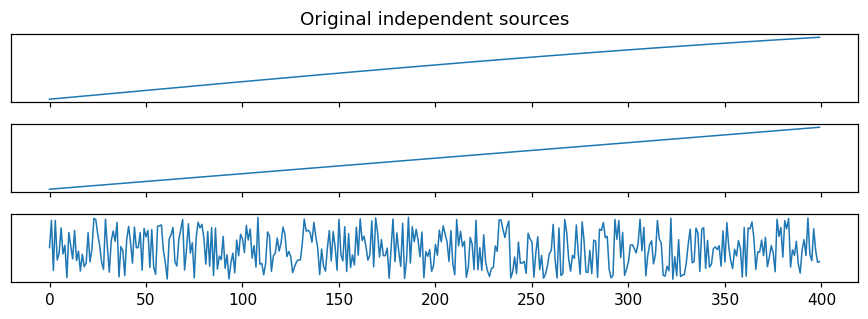

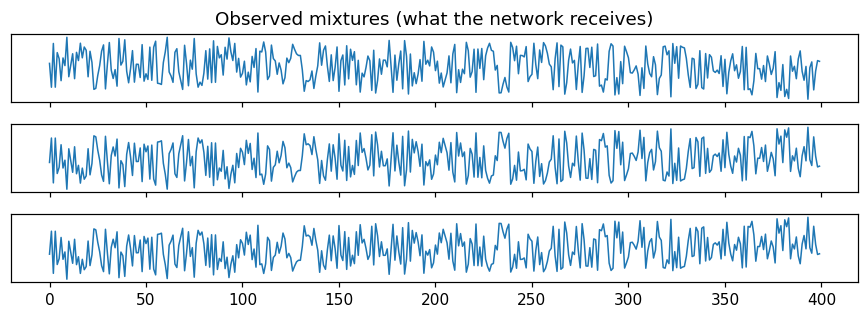

In [3]:
def show(M, title, n=400):
    fig, ax = plt.subplots(3, 1, figsize=(8, 3), sharex=True)
    for i in range(3):
        ax[i].plot(M[i, :n], lw=1)
        ax[i].set_yticks([])
    ax[0].set_title(title); plt.tight_layout(); plt.show()

show(S, "Original independent sources")
show(X, "Observed mixtures (what the network receives)")


## The EGHR learning rule

In [4]:
g   = lambda u: u**3                      # score function for sub-Gaussian prior
Efn = lambda u: 0.25 * (u**4).sum(0)      # E(u) = sum_i u_i^4 / 4   (per-sample scalar)

def corr_recovery(W, Z, S):
    Uo = W @ Z
    M = np.abs(np.corrcoef(Uo, S)[:3, 3:]).copy()
    best = []
    for _ in range(3):                    # greedy best permutation match
        i, j = np.unravel_index(np.argmax(M), M.shape)
        best.append(M[i, j]); M[i, :] = -1; M[:, j] = -1
    return np.array(best)

W = np.linalg.qr(rng.standard_normal((3, 3)))[0]   # start from a random rotation
lr, batch, n_epoch = 0.02, 200, 40
Ebar, hist = 1.0, []
for ep in range(n_epoch):
    for b in range(0, T, batch):
        idx = rng.integers(0, T, batch)
        z = Z[:, idx]
        u = W @ z
        E = Efn(u)
        Ebar = 0.99*Ebar + 0.01*E.mean()           # running estimate of <E(u)> = E0
        gate = (E - Ebar)                           # GLOBAL scalar error gate
        dW = -((gate * g(u)) @ z.T) / batch         # -(E-E0) g(u) z^T  (Hebbian, gated)
        W = W + lr * dW
        W /= np.linalg.norm(W, axis=1, keepdims=True)   # local per-neuron normalization
    hist.append(corr_recovery(W, Z, S).mean())

rec = corr_recovery(W, Z, S)
print("per-source |corr| with truth:", np.round(rec, 3), " mean:", round(rec.mean(), 3))


per-source |corr| with truth: [1. 1. 1.]  mean: 1.0


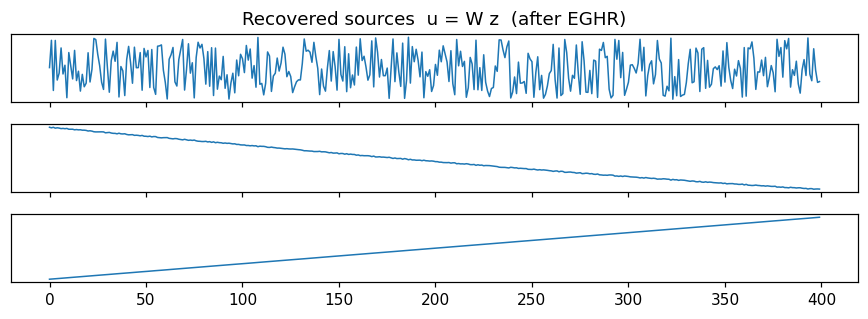

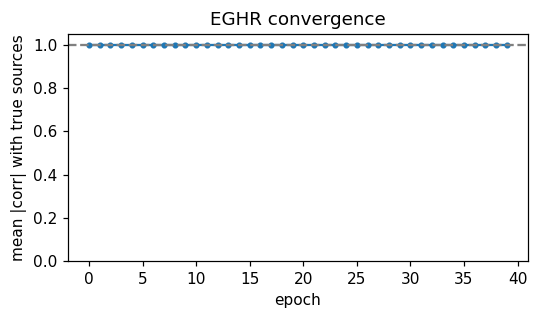

In [5]:
U_out = W @ Z
show(U_out, "Recovered sources  u = W z  (after EGHR)")

fig, ax = plt.subplots(1, 1, figsize=(5, 3))
ax.plot(hist, marker="o", ms=3)
ax.set_xlabel("epoch"); ax.set_ylabel("mean |corr| with true sources")
ax.set_title("EGHR convergence"); ax.set_ylim(0, 1.05); ax.axhline(1, ls="--", c="gray")
plt.tight_layout(); plt.show()


## Takeaways

- **Local ICA.** The EGHR separates independent sources using only signals available *at the
  synapse*: a presynaptic input, a postsynaptic nonlinearity, and **one global scalar** error.
- That global scalar is the **third factor** — exactly the motif that generalizes Hebb to a
  learning rule (cf. neuromodulators, reward, error). Demo 3 shows the same motif training a
  *recurrent* network.
- **Connection to L1:** with $\beta=1$ the same rule reduces to Oja-style PCA (Demo 1). One
  family, two classic computations — chosen by the objective.
